C:\Users\ygunj\AppData\Local\Temp\ipykernel_9156\3337865600.py:196: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


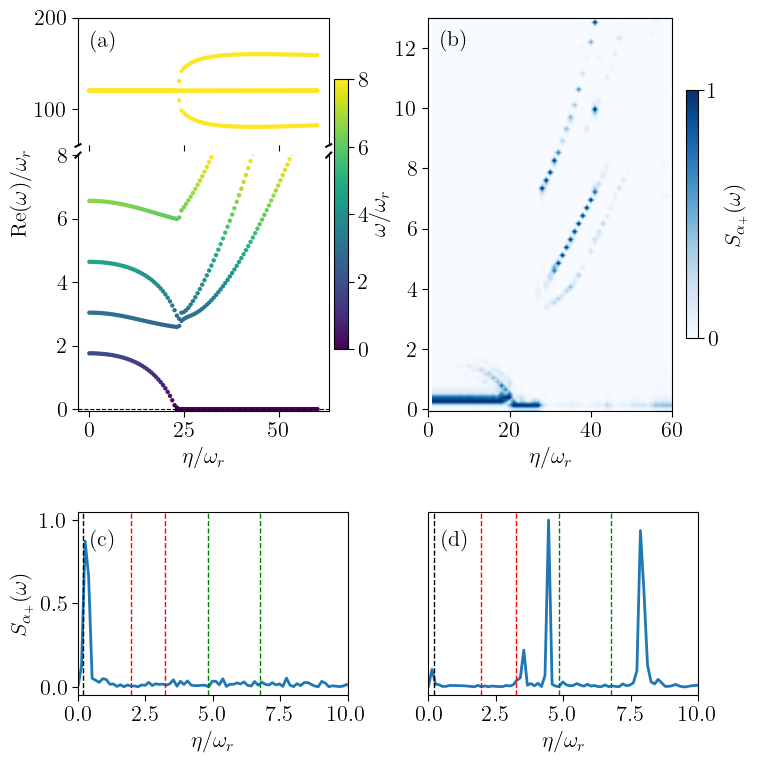

In [1]:
import numpy as np

# Path to the saved file
file_path = r"Figure_14_data.npz"

# Load the file
data = np.load(file_path)

# Extract all arrays
eigvals_all  = data['eigvals_all']
eta_scaled   = data['eta_scaled']
eta_list     = data['eta_list']
freq_shift   = data['freq_shift']
S_plot       = data['S_plot']
omega_r      = data['omega_r']
freq_scaled  = data['freq_scaled']
Sap          = data['Sap']
Sap1         = data['Sap1']


import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ============================================================
# PRL / LaTeX Style
# ============================================================
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 16,
    "axes.linewidth": 0.8,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.top": False,
    "ytick.right": False,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "legend.frameon": False
})

# ============================================================
# Figure layout
# ============================================================
fig = plt.figure(figsize=(8,8.8))

# Top row taller, bottom row shorter
gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1.5, 0.7],   # top row taller, bottom row shorter
    hspace=0.35,
    wspace=0.3
)

# ============================================================
# (9a) Collective spectrum (broken axis)
# ============================================================
subgs = gs[0,0].subgridspec(2,1, height_ratios=[1,2], hspace=0.05)
ax_top = fig.add_subplot(subgs[0])
ax_bot = fig.add_subplot(subgs[1], sharex=ax_top)

norm = Normalize(vmin=0, vmax=8)
cmap = plt.cm.viridis
sm = ScalarMappable(norm=norm, cmap=cmap)

for i in range(len(eta_scaled)):
    y = np.real(eigvals_all[i]) / omega_r
    x = np.full_like(y, eta_scaled[i])
    c = cmap(norm(y))
    ax_top.scatter(x, y, c=c, s=10, linewidths=0)
    ax_bot.scatter(x, y, c=c, s=10, linewidths=0)

ax_bot.set_ylim(-0.05, 8)
ax_top.set_ylim(60, 200)
ax_bot.axhline(0, ls='--', c='k', lw=0.8)

# ax_bot.set_xlabel(r'$\eta/\omega_r$')
fig.text(
    0.04, 0.68,   # adjust horizontal/vertical position
    r'$\mathrm{Re}(\omega)/\omega_r$',
    rotation=90,
    va='center'
)
ax_top.tick_params(labelbottom=False)

# Broken axis styling
ax_top.spines['bottom'].set_visible(False)
ax_bot.spines['top'].set_visible(False)

d = 0.01
kwargs = dict(transform=ax_top.transAxes, color='k', clip_on=False)
ax_top.plot((-d,+d),(-d,+d),**kwargs)
ax_top.plot((1-d,1+d),(-d,+d),**kwargs)
kwargs.update(transform=ax_bot.transAxes)
ax_bot.plot((-d,+d),(1-d,1+d),**kwargs)
ax_bot.plot((1-d,1+d),(1-d,1+d),**kwargs)
ax_bot.set_xlabel(r'$\eta/\omega_r$')
fig.colorbar(sm, ax=[ax_top, ax_bot], fraction=0.05, pad=0.02)
ax_top.text(
    0.05, 0.9,           # x=5% from left, y=90% from bottom
    r"(a)",              # text
    transform=ax_top.transAxes,  # coordinates in axes fraction
    fontsize=16,
    va='top',            # vertical alignment
    ha='left'            # horizontal alignment
)

# ============================================================
# (9b) 2D cavity spectrum
# ============================================================
ax2 = fig.add_subplot(gs[0,1])

cont = ax2.contourf(
    eta_list/omega_r,
    freq_shift,
    S_plot,
    levels=400,
    cmap='Blues'
)

ax2.set_xlim([0,60])
ax2.set_ylim([-0.05,13])
ax2.set_xlabel(r'$\eta/\omega_r$')
ax2.set_ylabel(r'$\omega/\omega_r$')
ax2.text(
    0.05, 0.97,           # x=5% from left, y=90% from bottom
    r"(b)",              # text
    transform=ax2.transAxes,  # coordinates in axes fraction
    fontsize=16,
    va='top',            # vertical alignment
    ha='left'            # horizontal alignment
)

cbar = fig.colorbar(cont, ax=ax2, fraction=0.046)
cbar.set_ticks([0, 1])
# optional: colorbar label (title)
cbar.set_label(r'$S_{\alpha_+}(\omega)$')

# ============================================================
# (9c) Sap vs eta
# ============================================================
ax3 = fig.add_subplot(gs[1,0])

ax3.plot(freq_scaled, Sap, lw=2)
ax3.set_xlabel(r'$\eta/\omega_r$')
ax3.set_ylabel(r'$S_{\alpha_+}(\omega)$')
ax3.set_xlim([0,10])
# Remove the default title
# ax3.set_title(r"(c)")  

# Place the label inside the plot at coordinates (x, y) in axes fraction
ax3.text(
    0.05, 0.9,           # x=5% from left, y=90% from bottom
    r"(c)",              # text
    transform=ax3.transAxes,  # coordinates in axes fraction
    fontsize=16,
    va='top',            # vertical alignment
    ha='left'            # horizontal alignment
)
ax3.axvline(4.84, color='g', ls='--', lw=1)
ax3.axvline(3.24, color='r', ls='--', lw=1)
ax3.axvline(6.76, color='g', ls='--', lw=1)
ax3.axvline(1.96, color='r', ls='--', lw=1)
ax3.axvline(0.2, color='black', ls='--', lw=1)


# ============================================================
# (9d) Sap1 vs eta
# ============================================================
ax4 = fig.add_subplot(gs[1,1])

ax4.plot(freq_scaled, Sap1, lw=2)
ax4.set_xlabel(r'$\eta/\omega_r$')
ax4.set_xlim([0,10])
ax4.set_ylabel("")
ax4.set_yticks([])
# ax4.spines['left'].set_visible(False)
ax4.text(
    0.05, 0.9,           # x=5% from left, y=90% from bottom
    r"(d)",              # text
    transform=ax4.transAxes,  # coordinates in axes fraction
    fontsize=16,
    va='top',            # vertical alignment
    ha='left'            # horizontal alignment
)
ax4.axvline(4.84, color='g', ls='--', lw=1)
ax4.axvline(3.24, color='r', ls='--', lw=1)
ax4.axvline(6.76, color='g', ls='--', lw=1)
ax4.axvline(1.96, color='r', ls='--', lw=1)
ax4.axvline(0.2, color='black', ls='--', lw=1)

plt.tight_layout()
plt.show()